## SQL Data Analysis using SQLite and Python

In [2]:
import sqlite3

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
conn=sqlite3.connect("sales_data.db")
cursor=conn.cursor()
print("database connected successfully")

In [36]:
cursor.execute("""create table sale(
order_id int primary key,
customer_name varchar(100),
product varchar(100),
category varchar(100),
quantity int,
price int not null,
city varchar(100)
)""")
conn.commit()

In [7]:
#inserting data

In [51]:
sql= "insert into sale values(?, ?, ?, ?, ?, ?, ?)"
val=[
    (1, 'Apurva', 'Laptop', 'Electronics', 2, 55000, 'Mumbai'),
    (2, 'Rahul', 'Phone', 'Electronics', 1, 30000, 'Pune'),
    (3, 'Sneha', 'Shoes', 'Fashion', 3, 2500, 'Delhi'),
    (4, 'Amit', 'Watch', 'Accessories', 2, 4000, 'Mumbai'),
    (5, 'Priya', 'Tablet', 'Electronics', 1, 20000, 'Bangalore')
]
cursor.executemany(sql,val)
conn.commit


<function Connection.commit()>

In [60]:
#SQL Queries

In [70]:
query="""Select * from sale"""
df=pd.read_sql(query,conn)
df

,order_id,customer_name,product,category,quantity,price,city
0,1,Apurva,Laptop,Electronics,2,55000,Mumbai
1,2,Rahul,Phone,Electronics,1,30000,Pune
2,3,Sneha,Shoes,Fashion,3,2500,Delhi
3,4,Amit,Watch,Accessories,2,4000,Mumbai
4,5,Priya,Tablet,Electronics,1,20000,Bangalore


In [68]:
query="""select order_id,customer_name,city from sale where city='Mumbai'"""
pd.read_sql(query,conn)

,order_id,customer_name,city
0,1,Apurva,Mumbai
1,4,Amit,Mumbai


The query filters customers specifically from Mumbai.<br>
It helps identify customer distribution based on city.

In [54]:
query = """SELECT *
FROM sale
WHERE city='Mumbai' AND category='Electronics' """
pd.read_sql(query, conn)

,order_id,customer_name,product,category,quantity,price,city
0,1,Apurva,Laptop,Electronics,2,55000,Mumbai


This query combines multiple conditions using AND.<br>
It helps identify customers from Mumbai who purchased Electronics products.<br>
Such filtering can help businesses target city-specific product demand and marketing campaigns.<br>

In [67]:
query = """SELECT *
FROM sale
WHERE price BETWEEN 5000 AND 40000"""
pd.read_sql(query, conn)

,order_id,customer_name,product,category,quantity,price,city
0,2,Rahul,Phone,Electronics,1,30000,Pune
1,5,Priya,Tablet,Electronics,1,20000,Bangalore


he query filters products within a specific price range.<br>
It helps analyze moderately priced products that may attract more customers.

In [66]:
query = """SELECT customer_name,
       price,
       product,
       CASE
           WHEN price >=20000 THEN 'Expensive'
           ELSE 'Affordable'
       END AS product_type
FROM sale"""
pd.read_sql(query, conn)

,customer_name,price,product,product_type
0,Apurva,55000,Laptop,Expensive
1,Rahul,30000,Phone,Expensive
2,Sneha,2500,Shoes,Affordable
3,Amit,4000,Watch,Affordable
4,Priya,20000,Tablet,Expensive


The query classifies products into “Expensive” and “Affordable” categories.<br>
Electronics products were mostly classified as expensive due to higher prices.

In [61]:
#Data Visualization

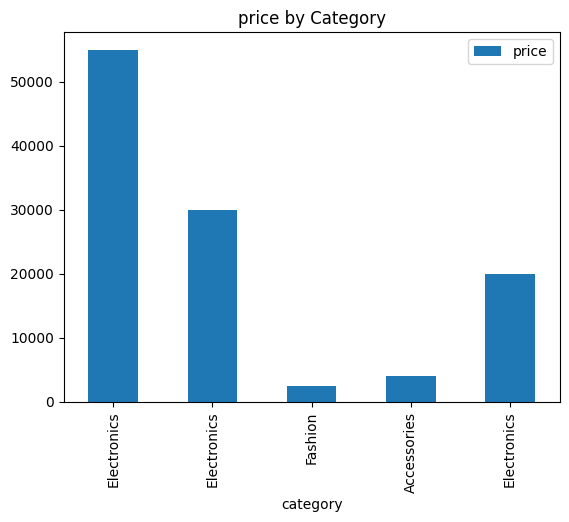

In [71]:
#barplot
df.plot(
    x='category',
    y='price',
    kind='bar'
)

plt.title("price by Category")
plt.show()

Electronics products generated the highest revenue among all categories.

In [77]:
df['revenue'] = df['quantity'] * df['price']
df

,order_id,customer_name,product,category,quantity,price,city,revenue
0,1,Apurva,Laptop,Electronics,2,55000,Mumbai,110000
1,2,Rahul,Phone,Electronics,1,30000,Pune,30000
2,3,Sneha,Shoes,Fashion,3,2500,Delhi,7500
3,4,Amit,Watch,Accessories,2,4000,Mumbai,8000
4,5,Priya,Tablet,Electronics,1,20000,Bangalore,20000


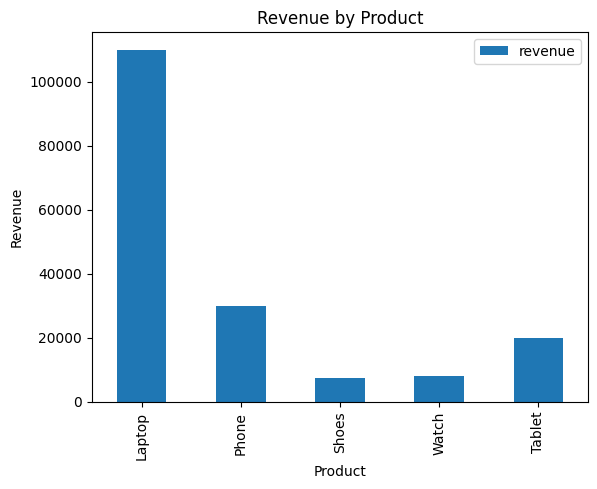

In [78]:
df.plot(
    x='product',
    y='revenue',
    kind='bar'
)

plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Revenue")

plt.show()

High-priced products mainly belonged to the Electronics category.<br>
Laptop sales contributed significantly to overall revenue.

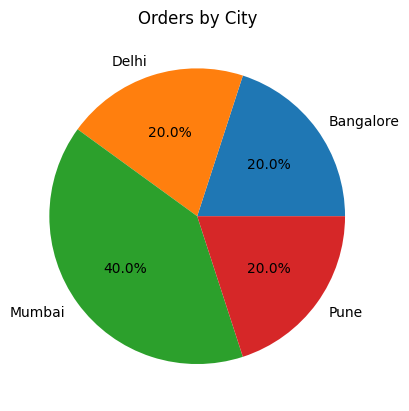

In [79]:
#piechart: orders by city
city_df = df.groupby('city')['order_id'].count()

city_df.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Orders by City")
plt.ylabel("")

plt.show()

Mumbai had the highest number of customer orders in the dataset.<br>

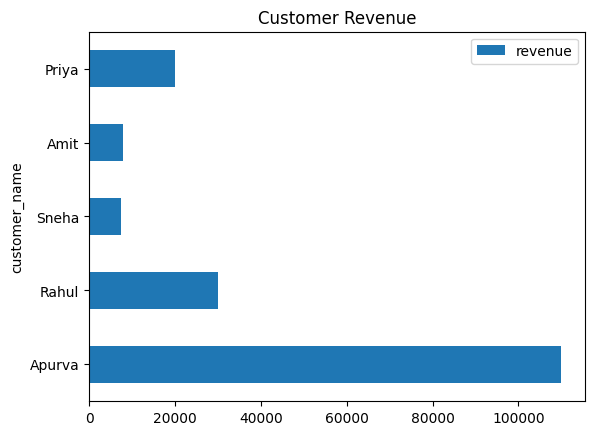

In [81]:
#horizontal bar graph
df.plot(
    x='customer_name',
    y='revenue',
    kind='barh'
)

plt.title("Customer Revenue")

plt.show()

SQL queries helped efficiently filter and analyze customer purchasing patterns.